# Tutorial: computing neutrino oscillation probabilities with `nuosc`

This notebook teaches you **how to use the code**, step by step, with many small examples.
It does **not** make the final plots of the project: that is your job (exercises at the end).
Run the cells in order (Shift+Enter) and read the comments in the code.

**Contents**

0. A two-minute reminder of the physics
1. Setting up (imports, plot style)
2. Your first probability
3. The oscillator object and its parameters
4. Channels: one probability or all nine
5. Vacuum or matter
6. Changing the oscillation parameters
7. Normal or inverted mass ordering
8. Neutrinos or antineutrinos
9. Many energies at once (energy scans at fixed baseline)
10. Changing the baseline, and scans in $L/E$
11. Ready-made experiment configurations
12. Plotting: a few basic examples
13. Common mistakes
14. Cheat sheet
15. Exercises

A more detailed reference for every option (matter on/off, NO/IO, $\nu/\bar\nu$, parameters, experiments) is in `GUIDE.md`.

**Units used everywhere:** energy $E$ in **GeV**, baseline $L$ in **km**, mass splittings $\Delta m^2$ in **eV²**,
matter density $\rho$ in **g/cm³**, CP phase $\delta_{CP}$ in **degrees**.

## 0. A two-minute reminder of the physics

A neutrino produced with flavour $\alpha$ ($e$, $\mu$ or $\tau$) can be detected, after travelling a distance $L$,
with a different flavour $\beta$. The probability $P(\nu_\alpha\to\nu_\beta)$ depends on

* the **energy** $E$ and the **baseline** $L$;
* six **oscillation parameters**: three mixing angles ($\theta_{12}, \theta_{13}, \theta_{23}$, we use $\sin^2\theta_{ij}$),
  the CP phase $\delta_{CP}$ and two mass splittings $\Delta m^2_{21}$, $\Delta m^2_{31}$;
* the **mass ordering**: normal (NO, $\Delta m^2_{31}>0$) or inverted (IO, $\Delta m^2_{31}<0$);
* whether we have **neutrinos or antineutrinos**;
* the **matter** crossed by the neutrinos (electrons in the Earth change the probabilities).

With only two flavours the probability would be
$$P(\nu_\mu\to\nu_\mu) \simeq 1 - \sin^2 2\theta\,\sin^2\!\left(1.267\,\frac{\Delta m^2[\mathrm{eV^2}]\,L[\mathrm{km}]}{E[\mathrm{GeV}]}\right),$$
so what matters in vacuum is the ratio $L/E$. `nuosc` computes the full three-flavour result, in vacuum or in
matter of constant density.

*Survival* channels ($\alpha=\beta$, e.g. $\nu_\mu\to\nu_\mu$) are also called **disappearance**;
*transition* channels ($\alpha\ne\beta$, e.g. $\nu_\mu\to\nu_e$) are called **appearance**.

## 1. Setting up

If you have not done it yet, install the package once, from the project folder (in a terminal):

```bash
pip install -e .
```

Then import what we need. `numpy` gives arrays and maths, `matplotlib` makes plots.

**Plot style:** `set_style(True)` applies the style of this project (the `latex_style` if you have it,
otherwise SciencePlots). If you prefer your own matplotlib settings, set `SET_STYLE = False`: then nothing
is changed. In both cases `c` is a list of colours you can use in your plots.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from nuosc import NeutrinoOscillator
from nuosc.plotting import set_style

SET_STYLE = True     # True: nuosc style (latex_style -> SciencePlots -> default); False: keep your own matplotlib settings
c = set_style(SET_STYLE)   # list of colours used in the plots

plot style: latex_style


## 2. Your first probability

Three lines: create an *oscillator* for a baseline of 1300 km, then ask for $P(\nu_\mu\to\nu_e)$ at 2.5 GeV.

In [ ]:
osc = NeutrinoOscillator(baseline=1300)      # L = 1300 km, default parameters
p = osc.matter("mu", "e", E=2.5)             # P(nu_mu -> nu_e) at E = 2.5 GeV, with matter effects
print(p)

0.06970057989110624


About 7%: out of 100 muon neutrinos of 2.5 GeV, about 7 arrive as electron neutrinos after 1300 km.
Let's print it more nicely with an f-string (`:.3f` means 3 decimals):

In [ ]:
print(f"P(nu_mu -> nu_e) = {p:.3f}")
print(f"P(nu_mu -> nu_e) = {100 * p:.1f} %")

P(nu_mu -> nu_e) = 0.070
P(nu_mu -> nu_e) = 7.0 %


## 3. The oscillator object and its parameters

`NeutrinoOscillator` is a Python *object*: it stores everything needed for the calculation.
When you create it you can choose:

| argument | meaning | default |
|---|---|---|
| `ordering` | `"NO"` or `"IO"` | `"NO"` |
| `baseline` | $L$ in km | 1300 |
| `rho` | matter density in g/cm³ | 2.8 |
| `antineutrino` | `False` (neutrinos) or `True` | `False` |
| `energy` | default energy grid in GeV | 0.2–10 GeV |
| any parameter | e.g. `delta_cp=270`, `s2_23=0.5` | NuFIT 6.0 |

`print(osc)` shows the current values. The defaults are the NuFIT 6.0 best fit (www.nu-fit.org).

In [ ]:
osc = NeutrinoOscillator(ordering="NO", baseline=1300, rho=2.8)
print(osc)

NeutrinoOscillator(NO, neutrino, L = 1300 km, rho = 2.8 g/cm^3)
  sin^2(th12) = 0.3080   (th12 = 33.71 deg)
  sin^2(th13) = 0.02215  (th13 = 8.56 deg)
  sin^2(th23) = 0.4700   (th23 = 43.28 deg)
  delta_CP    = 212.0 deg
  dm2_21      = 7.490e-05 eV^2
  dm2_31      = +2.5130e-03 eV^2
  dm2_32      = +2.4381e-03 eV^2


Each parameter is an **attribute** of the object: you read it with `osc.<name>`.
The names are `s2_12, s2_13, s2_23` ($\sin^2\theta_{ij}$), `delta_cp` (degrees), `dm2_21, dm2_31` (eV²).

In [ ]:
print("sin^2(theta_23) =", osc.s2_23)
print("theta_23        =", osc.theta_23, "degrees")      # angles in degrees, computed for you
print("delta_CP        =", osc.delta_cp, "degrees")
print("dm2_31          =", osc.dm2_31, "eV^2")
print("dm2_32          =", osc.dm2_32, "eV^2")          # = dm2_31 - dm2_21
print("baseline        =", osc.baseline, "km")
print("density         =", osc.rho, "g/cm^3")

print("\nall six parameters as a dictionary:")
print(osc.params)

sin^2(theta_23) = 0.47
theta_23        = 43.280093616242404 degrees
delta_CP        = 212.0 degrees
dm2_31          = 0.002513 eV^2
dm2_32          = 0.0024381 eV^2
baseline        = 1300 km
density         = 2.8 g/cm^3

all six parameters as a dictionary:
{'s2_12': 0.308, 's2_13': 0.02215, 's2_23': 0.47, 'delta_cp': 212.0, 'dm2_21': 7.49e-05, 'dm2_31': 0.002513}


The PMNS mixing matrix $U$ is also available (rows: $e,\mu,\tau$; columns: mass states 1, 2, 3).
$|U_{\alpha i}|^2$ tells how much of mass state $i$ there is in flavour $\alpha$: each row sums to 1.

In [ ]:
np.set_printoptions(precision=3, suppress=True)     # nicer printing of arrays
U2 = np.abs(osc.U) ** 2
print(U2)
print("row sums:", U2.sum(axis=1))

[[0.677 0.301 0.022]
 [0.112 0.428 0.46 ]
 [0.211 0.271 0.518]]
row sums: [1. 1. 1.]


## 4. Channels: one probability or all nine

The first two arguments are the **initial** and the **final** flavour: `"e"`, `"mu"` or `"tau"`.

In [ ]:
E = 2.5
print(f"P(mu -> e)   = {osc.matter('mu', 'e',   E=E):.4f}   (appearance)")
print(f"P(mu -> mu)  = {osc.matter('mu', 'mu',  E=E):.4f}   (disappearance / survival)")
print(f"P(mu -> tau) = {osc.matter('mu', 'tau', E=E):.4f}")

P(mu -> e)   = 0.0697   (appearance)
P(mu -> mu)  = 0.0098   (disappearance / survival)
P(mu -> tau) = 0.9205


**Check:** a $\nu_\mu$ must end up as *something*, so the three numbers add up to 1:

In [ ]:
total = osc.matter("mu", "e", E=E) + osc.matter("mu", "mu", E=E) + osc.matter("mu", "tau", E=E)
print(total)

1.0


If you do not give the flavours you get **all nine** probabilities at once, as a $3\times3$ array `P[initial, final]`
with the index 0 = $e$, 1 = $\mu$, 2 = $\tau$. So `P[1, 0]` is $P(\nu_\mu\to\nu_e)$.

In [ ]:
P = osc.matter(E=2.5)
print(P)
print("P(mu -> e) = P[1, 0] =", P[1, 0])
print("P(e -> mu) = P[0, 1] =", P[0, 1])       # not the same as P[1, 0]! (CP violation + matter)
print("rows sum to", P.sum(axis=1), "  columns sum to", P.sum(axis=0))

[[0.871 0.053 0.076]
 [0.07  0.01  0.921]
 [0.059 0.937 0.004]]
P(mu -> e) = P[1, 0] = 0.06970057989110624
P(e -> mu) = P[0, 1] = 0.05314999414614639
rows sum to [1. 1. 1.]   columns sum to [1. 1. 1.]


## 5. Vacuum or matter

There are two ways of computing the probability:

| method | what it does |
|---|---|
| `osc.vacuum(a, b, E)` | vacuum formula (no matter) |
| `osc.matter(a, b, E)` | constant matter density `osc.rho` (NuFast algorithm) |
| `osc.probability(a, b, E, matter=True / False)` | the same two, chosen with a flag |

The flag version is handy in loops: `for matter in [False, True]: ...`.

In [ ]:
print("vacuum:", osc.vacuum("mu", "e", E=2.5))
print("matter:", osc.matter("mu", "e", E=2.5))

for matter in [False, True]:
    p = osc.probability("mu", "e", E=2.5, matter=matter)
    print(f"matter = {matter!s:5s}  ->  P = {p:.4f}")

vacuum: 0.04910462371457644
matter: 0.06970057989110624
matter = False  ->  P = 0.0491
matter = True   ->  P = 0.0697


The **density** is the attribute `rho` (g/cm³). The Earth's crust is about 2.6–3 g/cm³. With `rho = 0`,
the "matter" calculation must give the vacuum result — a good sanity check:

In [ ]:
for rho in [0.0, 1.0, 2.8, 5.0, 10.0]:
    osc.rho = rho
    print(f"rho = {rho:4.1f} g/cm^3   P(mu->e) = {osc.matter('mu', 'e', E=2.5):.4f}")
print(f"vacuum               P(mu->e) = {osc.vacuum('mu', 'e', E=2.5):.4f}")

osc.rho = 2.8          # put it back!

rho =  0.0 g/cm^3   P(mu->e) = 0.0491
rho =  1.0 g/cm^3   P(mu->e) = 0.0564
rho =  2.8 g/cm^3   P(mu->e) = 0.0697
rho =  5.0 g/cm^3   P(mu->e) = 0.0850
rho = 10.0 g/cm^3   P(mu->e) = 0.1076
vacuum               P(mu->e) = 0.0491


> **Try it:** does the density change $P(\nu_\mu\to\nu_\mu)$ as much as $P(\nu_\mu\to\nu_e)$? Copy the cell above and change the channel.

In [ ]:
# your code here

## 6. Changing the oscillation parameters

Two equivalent ways:

* `osc.set_params(name=value, ...)` — one or more parameters at once;
* `osc.name = value` — one at a time.

`osc.reset()` goes back to the default (NuFIT) values. Here we change $\delta_{CP}$, the CP phase:

In [ ]:
for d in [0, 90, 180, 270]:
    osc.set_params(delta_cp=d)
    print(f"delta_CP = {d:3d} deg   P(mu->e) = {osc.matter('mu', 'e', E=2.5):.4f}")

osc.reset()
print("after reset: delta_CP =", osc.delta_cp)

delta_CP =   0 deg   P(mu->e) = 0.0598
delta_CP =  90 deg   P(mu->e) = 0.0451
delta_CP = 180 deg   P(mu->e) = 0.0616
delta_CP = 270 deg   P(mu->e) = 0.0763
after reset: delta_CP = 212.0


In [ ]:
# several parameters at once
osc.set_params(s2_23=0.5, delta_cp=270)
print(osc.params)

# one parameter with the attribute
osc.s2_13 = 0.020
print("s2_13 =", osc.s2_13)

# convenience: set dm2_32 instead of dm2_31 (dm2_31 = dm2_32 + dm2_21 is computed for you)
osc.set_params(dm2_32=2.45e-3)
print("dm2_31 =", osc.dm2_31)

osc.reset()

{'s2_12': 0.308, 's2_13': 0.02215, 's2_23': 0.5, 'delta_cp': 270.0, 'dm2_21': 7.49e-05, 'dm2_31': 0.002513}
s2_13 = 0.02
dm2_31 = 0.0025249


NeutrinoOscillator(NO, neutrino, L = 1300 km, rho = 2.8 g/cm^3)
  sin^2(th12) = 0.3080   (th12 = 33.71 deg)
  sin^2(th13) = 0.02215  (th13 = 8.56 deg)
  sin^2(th23) = 0.4700   (th23 = 43.28 deg)
  delta_CP    = 212.0 deg
  dm2_21      = 7.490e-05 eV^2
  dm2_31      = +2.5130e-03 eV^2
  dm2_32      = +2.4381e-03 eV^2

You can also give parameters directly when you create the oscillator:

In [ ]:
osc_max = NeutrinoOscillator(baseline=1300, s2_23=0.5, delta_cp=270)
print(osc_max)

NeutrinoOscillator(NO, neutrino, L = 1300 km, rho = 2.8 g/cm^3)
  sin^2(th12) = 0.3080   (th12 = 33.71 deg)
  sin^2(th13) = 0.02215  (th13 = 8.56 deg)
  sin^2(th23) = 0.5000   (th23 = 45.00 deg)
  delta_CP    = 270.0 deg
  dm2_21      = 7.490e-05 eV^2
  dm2_31      = +2.5130e-03 eV^2
  dm2_32      = +2.4381e-03 eV^2


> **Try it:** how does $P(\nu_\mu\to\nu_\mu)$ at 2.5 GeV change when $\sin^2\theta_{23}$ goes from 0.40 to 0.60?

In [ ]:
# your code here

## 7. Normal or inverted mass ordering

`osc.ordering = "IO"` (or `"NO"`) switches the ordering. **Careful:** changing the ordering **reloads all the
default parameters of that ordering** (NuFIT has different best fits for NO and IO, and $\Delta m^2_{31}$ changes sign).
Anything you changed by hand before is lost, so: first choose the ordering, then change the parameters.

In [ ]:
osc = NeutrinoOscillator(baseline=1300)
for o in ["NO", "IO"]:
    osc.ordering = o
    print(f"{o}: dm2_31 = {osc.dm2_31:+.3e} eV^2, delta_CP = {osc.delta_cp:5.1f}, "
          f"P(mu->e) matter = {osc.matter('mu', 'e', E=2.5):.4f}, vacuum = {osc.vacuum('mu', 'e', E=2.5):.4f}")

NO: dm2_31 = +2.513e-03 eV^2, delta_CP = 212.0, P(mu->e) matter = 0.0697, vacuum = 0.0491
IO: dm2_31 = -2.409e-03 eV^2, delta_CP = 274.0, P(mu->e) matter = 0.0393, vacuum = 0.0620


Notice that NO and IO differ much more in **matter** than in vacuum: matter effects are what make the ordering
measurable at long-baseline experiments.

The right way to compare the two orderings with the *same* $\delta_{CP}$:

In [ ]:
osc_no = NeutrinoOscillator("NO", baseline=1300, delta_cp=0)
osc_io = NeutrinoOscillator("IO", baseline=1300, delta_cp=0)
print(osc_no.matter("mu", "e", E=2.5), osc_io.matter("mu", "e", E=2.5))

0.05980841257489741 0.029717226430399323


## 8. Neutrinos or antineutrinos

The attribute `antineutrino` (`True` / `False`) switches between $\nu$ and $\bar\nu$. The flavour names stay the same:
with `antineutrino=True`, `("mu", "e")` means $\bar\nu_\mu\to\bar\nu_e$.

For antineutrinos the code changes the sign of $\delta_{CP}$ and of the matter potential. A difference between
$P(\nu_\mu\to\nu_e)$ and $P(\bar\nu_\mu\to\bar\nu_e)$ in vacuum is CP violation; in matter there is an extra
difference due to the matter itself.

In [ ]:
osc = NeutrinoOscillator(baseline=1300)

osc.antineutrino = False
p_nu = osc.matter("mu", "e", E=2.5)
osc.antineutrino = True
p_nubar = osc.matter("mu", "e", E=2.5)
osc.antineutrino = False          # put it back!

print(f"P(nu_mu    -> nu_e   ) = {p_nu:.4f}")
print(f"P(nubar_mu -> nubar_e) = {p_nubar:.4f}")
print(f"asymmetry (P - Pbar)/(P + Pbar) = {(p_nu - p_nubar) / (p_nu + p_nubar):.3f}")

P(nu_mu    -> nu_e   ) = 0.0697
P(nubar_mu -> nubar_e) = 0.0197
asymmetry (P - Pbar)/(P + Pbar) = 0.559


Often it is simplest to keep **two oscillators**, one for $\nu$ and one for $\bar\nu$:

In [ ]:
nu = NeutrinoOscillator("NO", baseline=1300)
nubar = NeutrinoOscillator("NO", baseline=1300, antineutrino=True)
print(nu.matter("mu", "e", E=2.5), nubar.matter("mu", "e", E=2.5))

0.06970057989110624 0.019714255425192784


> **Try it:** with $\delta_{CP} = 0$ and in **vacuum**, are $P(\nu_\mu\to\nu_e)$ and $P(\bar\nu_\mu\to\bar\nu_e)$ equal?
> And in matter?

In [ ]:
# your code here

## 9. Many energies at once: energy scans at fixed baseline

Instead of one number you can pass a **numpy array** of energies, and you get an array of probabilities back
(one per energy). This is how you make a curve $P(E)$.

Useful numpy functions:

* `np.linspace(a, b, n)`: `n` equally spaced numbers from `a` to `b`;
* `np.geomspace(a, b, n)`: equally spaced on a log scale (useful for wide energy ranges);
* `np.argmax(x)`, `np.argmin(x)`: position of the largest / smallest element.

In [ ]:
osc = NeutrinoOscillator(baseline=1300)

E = np.linspace(0.5, 5.0, 10)                 # 10 energies from 0.5 to 5 GeV
P_mumu = osc.matter("mu", "mu", E)            # 10 probabilities

print("E     :", E)
print("P_mumu:", P_mumu)
print("shapes:", E.shape, P_mumu.shape)

E     : [0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]
P_mumu: [0.054 0.382 0.803 0.192 0.01  0.057 0.171 0.289 0.394 0.482]
shapes: (10,) (10,)


In [ ]:
# the same, as a small table
for e, p in zip(E, P_mumu):
    print(f"E = {e:4.2f} GeV   P(mu->mu) = {p:.3f}")

E = 0.50 GeV   P(mu->mu) = 0.054
E = 1.00 GeV   P(mu->mu) = 0.382
E = 1.50 GeV   P(mu->mu) = 0.803
E = 2.00 GeV   P(mu->mu) = 0.192
E = 2.50 GeV   P(mu->mu) = 0.010
E = 3.00 GeV   P(mu->mu) = 0.057
E = 3.50 GeV   P(mu->mu) = 0.171
E = 4.00 GeV   P(mu->mu) = 0.289
E = 4.50 GeV   P(mu->mu) = 0.394
E = 5.00 GeV   P(mu->mu) = 0.482


With a **fine grid** (thousands of points) you can find where the probability has a minimum or a maximum.
The first minimum of $P(\nu_\mu\to\nu_\mu)$ is the *first oscillation maximum* (maximal disappearance):

In [ ]:
E = np.linspace(1.0, 6.0, 5000)
P_mumu = osc.matter("mu", "mu", E)
i = np.argmin(P_mumu)
print(f"minimum of P(mu->mu) = {P_mumu[i]:.4f} at E = {E[i]:.3f} GeV")

# compare with the two-flavour estimate: 1.267 dm2 L / E = pi/2
E_est = 1.267 * osc.dm2_32 * osc.baseline / (np.pi / 2)
print(f"two-flavour estimate: E = {E_est:.3f} GeV")

minimum of P(mu->mu) = 0.0079 at E = 2.569 GeV
two-flavour estimate: E = 2.557 GeV


Without a flavour you get the full matrix for every energy: an array of shape `(3, 3, number of energies)`.

In [ ]:
P_all = osc.matter(E=E)
print(P_all.shape)
P_mue = P_all[1, 0]                # the whole curve P(mu -> e)
print(P_mue.shape)

(3, 3, 5000)
(5000,)


Every oscillator also has a **default energy grid**, `osc.energy`, used when you do not pass `E`:

In [ ]:
print(osc.energy[:3], "...", osc.energy[-1], "  (", len(osc.energy), "points )")
P_default = osc.matter("mu", "mu")          # same as osc.matter("mu", "mu", osc.energy)
osc.energy = np.linspace(0.5, 8, 1000)       # you can replace it

[0.2   0.205 0.21 ] ... 10.0   ( 2000 points )


## 10. Changing the baseline, and scans in $L/E$

The baseline is the attribute `baseline`, or you can pass `L=` directly to `matter`, `vacuum` or `probability`
(this does not change `osc.baseline`):

In [ ]:
osc = NeutrinoOscillator()
for L in [295, 810, 1300]:
    print(f"L = {L:4d} km   P(mu->e) at 2 GeV = {osc.matter('mu', 'e', E=2.0, L=L):.4f}")

L =  295 km   P(mu->e) at 2 GeV = 0.0076
L =  810 km   P(mu->e) at 2 GeV = 0.0480
L = 1300 km   P(mu->e) at 2 GeV = 0.0746


### Scans in $L/E$

In **vacuum** the probability depends only on $L/E$. To compute it as a function of $L/E$ at fixed $L$:

1. make an array of $L/E$ values (km/GeV);
2. compute the energies $E = L / (L/E)$;
3. pass these energies (and the baseline).

In [ ]:
LE = np.array([250.0, 500.0, 750.0, 1000.0])     # km/GeV

for L in [295, 810, 1300]:
    E = L / LE                                    # step 2
    p_vac = osc.vacuum("mu", "mu", E=E, L=L)
    print(f"L = {L:4d} km:  E = {np.round(E, 3)}  ->  P_vacuum = {np.round(p_vac, 4)}")

L =  295 km:  E = [1.18  0.59  0.393 0.295]  ->  P_vacuum = [0.511 0.007 0.478 0.996]
L =  810 km:  E = [3.24 1.62 1.08 0.81]  ->  P_vacuum = [0.511 0.007 0.478 0.996]
L = 1300 km:  E = [5.2   2.6   1.733 1.3  ]  ->  P_vacuum = [0.511 0.007 0.478 0.996]


Same $L/E$ ⇒ same vacuum probability, for every baseline. **In matter** this is no longer exactly true:

In [ ]:
for L in [295, 810, 1300]:
    E = L / LE
    p_mat = osc.matter("mu", "e", E=E, L=L)
    print(f"L = {L:4d} km:  P_matter(mu->e) = {np.round(p_mat, 4)}")

L =  295 km:  P_matter(mu->e) = [0.021 0.053 0.041 0.005]
L =  810 km:  P_matter(mu->e) = [0.022 0.06  0.053 0.01 ]
L = 1300 km:  P_matter(mu->e) = [0.023 0.067 0.065 0.016]


### Scans in $L$ at fixed energy, and 2D grids

`E` and `L` can be arrays at the same time: numpy *broadcasts* them. With `np.meshgrid` you can build a 2D grid
of $(E, L)$ and get a 2D array of probabilities (useful for colour maps).

In [ ]:
L = np.linspace(100, 3000, 6)
print("P(mu->e) vs L at 2 GeV:", np.round(osc.matter("mu", "e", E=2.0, L=L), 4))

E_grid, L_grid = np.meshgrid(np.linspace(0.5, 5, 50), np.linspace(100, 3000, 40))
P_grid = osc.matter("mu", "e", E=E_grid, L=L_grid)
print("grid shapes:", E_grid.shape, P_grid.shape)

P(mu->e) vs L at 2 GeV: [0.001 0.036 0.074 0.044 0.004 0.054]
grid shapes: (40, 50) (40, 50)


## 11. Ready-made experiment configurations

The four long-baseline accelerator experiments (T2K, Hyper-K, NOvA, DUNE) are already configured in
`nuosc/experiments.py`, with

* `baseline` (km) and `rho` (average density along the path),
* `E_peak`: the typical energy of the beam (where the flux is largest),
* `E_range`: a sensible energy range for plots,
* `antineutrino`: the default beam mode.

Let's look at them:

In [ ]:
from nuosc import get_experiment

LBL = ["T2K", "HyperK", "NOvA", "DUNE"]      # long-baseline experiments
print(f"{'':8s} {'L [km]':>8s} {'rho':>6s} {'E_peak [GeV]':>13s}  E_range [GeV]")
for name in LBL:
    cfg = get_experiment(name)
    print(f"{name:8s} {cfg['baseline']:8.1f} {cfg['rho']:6.3f} {cfg['E_peak']:13g}  {cfg['E_range']}")

           L [km]    rho  E_peak [GeV]  E_range [GeV]
T2K         295.0  2.600           0.6  (0.1, 3.0)
HyperK      295.0  2.600           0.6  (0.1, 3.0)
NOvA        810.0  2.840             2  (0.3, 6.0)
DUNE       1300.0  2.848           2.5  (0.3, 8.0)


`get_experiment(name)` returns the configuration as a dictionary, and
`NeutrinoOscillator.from_experiment(name, ...)` creates an oscillator with baseline, density and energy grid
already set. You can still choose the ordering, $\nu$ or $\bar\nu$, and any parameter.

In [ ]:
cfg = get_experiment("NOvA")
print(cfg["baseline"], "km,", cfg["E_peak"], "GeV,", cfg["E_range"])

nova = NeutrinoOscillator.from_experiment("NOvA")
print(nova)
print("energy grid:", nova.energy[0], "to", nova.energy[-1], "GeV")
print(f"P(mu->e) at the peak energy: {nova.matter('mu', 'e', E=cfg['E_peak']):.4f}")

810.0 km, 2.0 GeV, (0.3, 6.0)
NeutrinoOscillator(NO, neutrino, L = 810.0 km, rho = 2.84 g/cm^3)
  sin^2(th12) = 0.3080   (th12 = 33.71 deg)
  sin^2(th13) = 0.02215  (th13 = 8.56 deg)
  sin^2(th23) = 0.4700   (th23 = 43.28 deg)
  delta_CP    = 212.0 deg
  dm2_21      = 7.490e-05 eV^2
  dm2_31      = +2.5130e-03 eV^2
  dm2_32      = +2.4381e-03 eV^2
energy grid: 0.3 to 6.0 GeV
P(mu->e) at the peak energy: 0.0481


In [ ]:
# the same experiment, antineutrino beam, inverted ordering, delta_CP = 0
nova_bar_io = NeutrinoOscillator.from_experiment("NOvA", ordering="IO", antineutrino=True, delta_cp=0)
print(f"P(mubar->ebar), IO, delta = 0: {nova_bar_io.matter('mu', 'e', E=cfg['E_peak']):.4f}")

# all probabilities on the experiment's own energy grid (no E needed)
P_curve = nova.matter("mu", "e")
print(P_curve.shape)

P(mubar->ebar), IO, delta = 0: 0.0488
(2000,)


A loop over experiments is the typical pattern for comparisons:

In [ ]:
for name in ["T2K", "HyperK", "NOvA", "DUNE"]:
    cfg = get_experiment(name)
    o = NeutrinoOscillator.from_experiment(name)
    print(f"{name:7s} L = {o.baseline:6.0f} km   E_peak = {cfg['E_peak']:4.1f} GeV   "
          f"L/E = {o.baseline / cfg['E_peak']:5.0f} km/GeV   P(mu->mu) = {o.matter('mu', 'mu', E=cfg['E_peak']):.3f}")

T2K     L =    295 km   E_peak =  0.6 GeV   L/E =   492 km/GeV   P(mu->mu) = 0.009
HyperK  L =    295 km   E_peak =  0.6 GeV   L/E =   492 km/GeV   P(mu->mu) = 0.009
NOvA    L =    810 km   E_peak =  2.0 GeV   L/E =   405 km/GeV   P(mu->mu) = 0.101
DUNE    L =   1300 km   E_peak =  2.5 GeV   L/E =   520 km/GeV   P(mu->mu) = 0.010


## 12. Plotting: a few basic examples

A plot is just `plt.plot(x, y)`. These examples use the **disappearance** channel; the appearance channel and the
comparisons between experiments are left for the exercises.

**Example 1:** one curve.

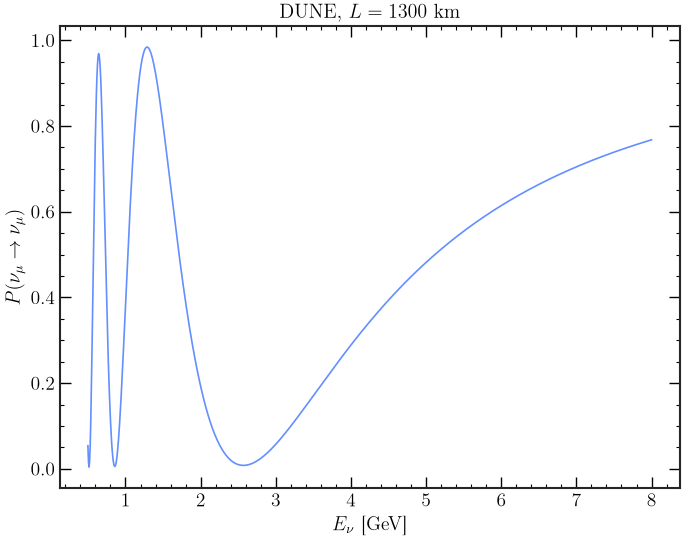

In [ ]:
osc = NeutrinoOscillator.from_experiment("DUNE")
E = np.linspace(0.5, 8, 1000)

plt.plot(E, osc.matter("mu", "mu", E))
plt.xlabel(r"$E_\nu$ [GeV]")
plt.ylabel(r"$P(\nu_\mu\to\nu_\mu)$")
plt.title("DUNE, $L = 1300$ km")
plt.show()

**Example 2:** several curves with a legend, using `label=` and the colours `c[0]`, `c[1]`, ...

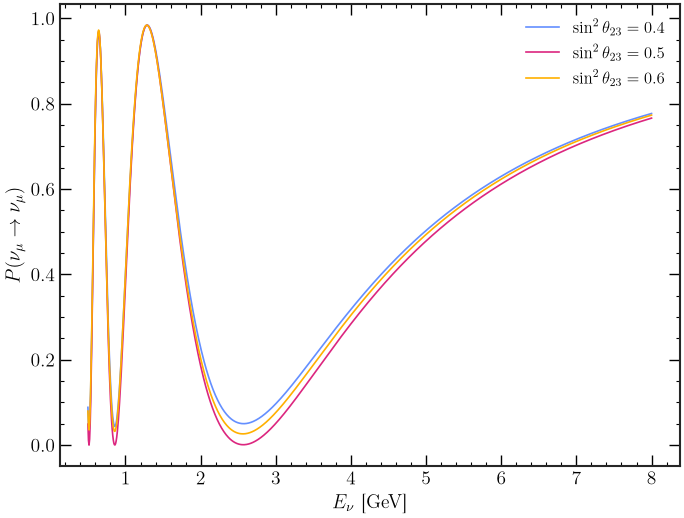

In [ ]:
for i, s23 in enumerate([0.40, 0.50, 0.60]):
    osc.set_params(s2_23=s23)
    plt.plot(E, osc.matter("mu", "mu", E), color=c[i], label=rf"$\sin^2\theta_{{23}} = {s23}$")
osc.reset()

plt.xlabel(r"$E_\nu$ [GeV]")
plt.ylabel(r"$P(\nu_\mu\to\nu_\mu)$")
plt.legend()
plt.show()

**Example 3:** a figure with two panels (`plt.subplots`), vs $E$ and vs $L/E$. Dashed lines: `ls="--"`.

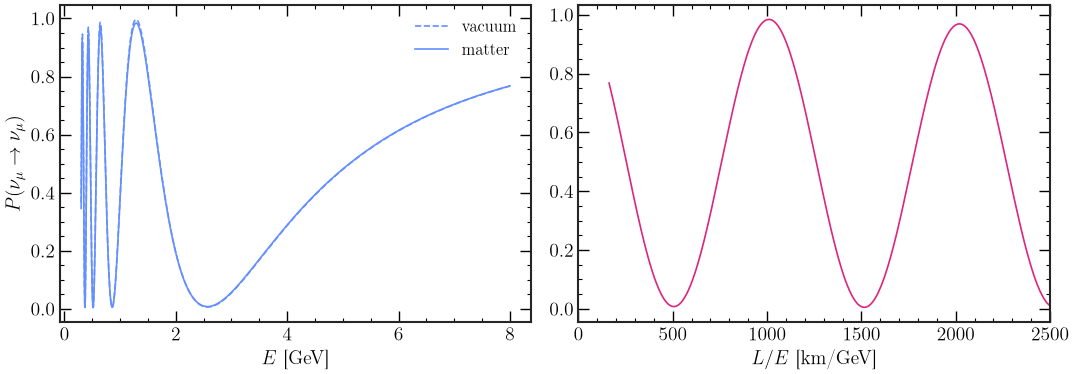

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

E = np.linspace(0.3, 8, 2000)
ax1.plot(E, osc.vacuum("mu", "mu", E), color=c[0], ls="--", label="vacuum")
ax1.plot(E, osc.matter("mu", "mu", E), color=c[0], label="matter")
ax1.set_xlabel(r"$E$ [GeV]")
ax1.set_ylabel(r"$P(\nu_\mu\to\nu_\mu)$")
ax1.legend()

LE = osc.baseline / E
ax2.plot(LE, osc.matter("mu", "mu", E), color=c[1])
ax2.set_xlabel(r"$L/E$ [km/GeV]")
ax2.set_xlim(0, 2500)

plt.tight_layout()
plt.show()

## 13. Common mistakes

| mistake | what happens | fix |
|---|---|---|
| energy in MeV | `E=600` means 600 GeV! | use GeV: `E=0.6` |
| `delta_cp` in radians | `delta_cp=np.pi` means 3.14 degrees | use degrees, or `np.degrees(...)` |
| changing the ordering after the parameters | the ordering reloads the defaults | set the ordering **first** |
| forgetting `antineutrino = False` after using `True` | later results are for antineutrinos | reset it, or use two oscillators |
| changing `rho` / parameters in a loop and not restoring them | the next cells use the modified values | `osc.reset()`, or create a new oscillator |
| mixing up `P[1, 0]` and `P[0, 1]` | $\nu_e\to\nu_\mu$ instead of $\nu_\mu\to\nu_e$ | first index = initial flavour |

## 14. Instructions

```python
from nuosc import NeutrinoOscillator, get_experiment

osc = NeutrinoOscillator(ordering="NO", baseline=1300, rho=2.8)      # create
osc = NeutrinoOscillator.from_experiment("DUNE", ordering="IO")      # from an experiment
cfg = get_experiment("DUNE"); cfg["baseline"], cfg["E_peak"], cfg["E_range"]

osc.matter("mu", "e", E)            # P(nu_mu -> nu_e) in matter  (E: number or array, GeV)
osc.vacuum("mu", "e", E)            # ... in vacuum
osc.probability("mu", "e", E, matter=False)
osc.matter(E=E)                     # all 9 channels: P[initial, final, ...]
osc.matter("mu", "e", E=E, L=L)     # other baseline (km)

osc.set_params(delta_cp=270, s2_23=0.5);  osc.reset()
osc.ordering = "IO"                 # reloads the IO defaults
osc.antineutrino = True             # antineutrinos
osc.rho = 0.0                       # density (0 = vacuum)
osc.baseline = 810                  # km
osc.params, osc.U, osc.dm2_32, osc.theta_23
```

## 15. Exercises


**Exercise 1: vacuum vs matter at the four experiments.**
For T2K, Hyper-K, NOvA and DUNE, set the baseline and density of the experiment and study the appearance
channel $P(\nu_\mu\to\nu_e)$ and the disappearance channel $P(\nu_\mu\to\nu_\mu)$, comparing the vacuum and the matter formulas, for neutrinos and antineutrinos and for both
mass orderings.

* Plot the probabilities as a function of energy over the energy range of each experiment, and mark its typical
  energy.
* At the typical energy of each experiment, quantify how big the matter effect is (e.g. the relative
  difference between matter and vacuum) and compare the four experiments.

*Questions:* Which experiment has the largest matter effect, and why (think of $L$ and $E$)? Is it an
enhancement or a suppression for $\nu$ in NO? What changes for $\bar\nu$ and for IO? Which channel is affected,
and which is almost insensitive? What happens in vacuum: what do the probabilities depend on, why are T2K and
Hyper-K identical, and what do you see if you plot the vacuum curves vs $L/E$?

**Exercise 2: the dependence on $\delta_{CP}$.**
Using both the vacuum and the matter formulas, study how $P(\nu_\mu\to\nu_e)$ and $P(\nu_\mu\to\nu_\mu)$ change
when you vary $\delta_{CP}$ (for example $0°, 90°, 180°, 270°$, then a full scan from $0°$ to $360°$), for the four
experiments, for neutrinos and antineutrinos.

* Look at the probabilities vs energy for the different values of $\delta_{CP}$.
* At the typical energy of each experiment, look at the probability as a function of $\delta_{CP}$.

*Questions:* How large is the effect of $\delta_{CP}$ in the two channels? Where in energy is it largest? Which
values of $\delta_{CP}$ give the largest and the smallest appearance probability, for $\nu$ and for $\bar\nu$? Do
$\delta_{CP}$ and $360°-\delta_{CP}$ give the same result? Does matter change the picture? Why is the
disappearance channel not the place to measure $\delta_{CP}$?

In [ ]:
# your code here